# Protocolo de EDA ponta a ponta

**Tema:** Preparação de Dados › Análise Exploratória (EDA)

Este notebook aplica o protocolo de 4 etapas do `teoria.pdf` a um dataset
sintético de e-commerce, com os defeitos comuns de dado real embutidos de
propósito: identificador numérico, valores nulos, categoria rara,
duplicatas, e uma coluna de vazamento escondida.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
pd.set_option("display.max_columns", 20)
print("pronto")

pronto


## 0. Construindo um dataset com defeitos realistas

Um cadastro de 4.000 pedidos, com: um `id_pedido` numérico (não é
quantidade!), nulos em `frete` (MCAR simulado), uma categoria de canal com
frequência quase nula, algumas linhas duplicadas por erro de reenvio, e uma
coluna `dias_ate_confirmacao` que só existe **depois** do pedido ser
confirmado — um vazamento clássico se o alvo for "o pedido será confirmado?".

In [2]:
n = 4000
canal = rng.choice(["orgânico", "pago", "email", "afiliado", "influencer"],
                    n, p=[0.35, 0.30, 0.15, 0.15, 0.05])
ticket = rng.lognormal(np.log(150), 0.7, n)
frete = np.where(ticket > 200, 0.0, rng.normal(18, 5, n))
idade_conta_dias = rng.exponential(400, n)
confirmado = (rng.random(n) < (0.7 + 0.2 * (canal == "orgânico"))).astype(int)
dias_ate_confirmacao = np.where(confirmado == 1, rng.exponential(2, n), np.nan)

pedidos = pd.DataFrame({
    "id_pedido": np.arange(100000, 100000 + n),
    "canal": canal,
    "ticket": ticket.round(2),
    "frete": frete.round(2),
    "idade_conta_dias": idade_conta_dias.round(1),
    "confirmado": confirmado,
    "dias_ate_confirmacao": dias_ate_confirmacao,
})

# nulos MCAR em frete (~5%)
idx_nulo = rng.choice(n, size=int(0.05 * n), replace=False)
pedidos.loc[idx_nulo, "frete"] = np.nan

# categoria rara: 6 pedidos de um canal "beta_test" quase inexistente
pedidos.loc[rng.choice(n, 6, replace=False), "canal"] = "beta_test"

# duplicatas por reenvio de formulário
pedidos = pd.concat([pedidos, pedidos.sample(15, random_state=1)], ignore_index=True)

print(f"shape: {pedidos.shape}")
pedidos.head()

shape: (4015, 7)


,id_pedido,canal,ticket,frete,idade_conta_dias,confirmado,dias_ate_confirmacao
0,100000,pago,75.98,17.63,300.8,0,NaN
1,100001,afiliado,42.51,15.38,412.7,1,1.695004
2,100002,email,199.34,21.79,240.7,1,5.703323
3,100003,orgânico,67.47,14.73,305.5,1,1.094106
4,100004,orgânico,110.28,19.97,123.7,1,0.811525


## Etapa 1 — Forma e proveniência

In [3]:
print(f"linhas: {len(pedidos)}   colunas: {pedidos.shape[1]}")
print(f"duplicatas EXATAS (todas as colunas): {pedidos.duplicated().sum()}")
print(f"duplicatas por id_pedido (deveria ser único): "
      f"{pedidos['id_pedido'].duplicated().sum()}")

print("\ndtypes:")
print(pedidos.dtypes)

linhas: 4015   colunas: 7
duplicatas EXATAS (todas as colunas): 15
duplicatas por id_pedido (deveria ser único): 15

dtypes:
id_pedido                 int64
canal                       str
ticket                  float64
frete                   float64
idade_conta_dias        float64
confirmado                int64
dias_ate_confirmacao    float64
dtype: object


**Achado imediato:** `id_pedido` é `int64`, mas é um **identificador**, não
uma quantidade. Se alguém rodar `pedidos.describe()` sem pensar, vai receber
uma "média de id_pedido" — um número sem nenhum significado.

In [4]:
pedidos_limpo = pedidos.drop_duplicates().reset_index(drop=True)
print(f"linhas após remover duplicatas exatas: {len(pedidos_limpo)} "
      f"(eram {len(pedidos)})")

linhas após remover duplicatas exatas: 4000 (eram 4015)


## Etapa 2 — Perfilamento univariado

In [5]:
def perfil(df):
    linhas = []
    for col in df.columns:
        s = df[col]
        linhas.append({
            "coluna": col,
            "dtype": str(s.dtype),
            "% nulos": s.isna().mean() * 100,
            "cardinalidade": s.nunique(),
            "% zeros": (s == 0).mean() * 100 if pd.api.types.is_numeric_dtype(s) else np.nan,
        })
    return pd.DataFrame(linhas).set_index("coluna")


print(perfil(pedidos_limpo).round(2).to_string())

                        dtype  % nulos  cardinalidade  % zeros
coluna                                                        
id_pedido               int64     0.00           4000     0.00
canal                     str     0.00              6      NaN
ticket                float64     0.00           3732     0.00
frete                 float64     5.00           1416    31.67
idade_conta_dias      float64     0.00           3175     0.02
confirmado              int64     0.00              2    24.08
dias_ate_confirmacao  float64    24.08           3037     0.00


**Dois sinais para investigar:**
- `dias_ate_confirmacao` tem ~20-25% de nulos — mas não é MCAR: são nulos
  **exatamente** onde `confirmado == 0`. Isso não é "dado faltante", é
  **estrutural** (o evento não aconteceu, não existe valor a preencher).
- `frete` tem nulos genuinamente dispersos — candidato a MCAR/MAR de verdade,
  tratado no módulo 2.

In [6]:
correlacao_nulo_confirmado = pedidos_limpo["dias_ate_confirmacao"].isna().astype(int)
print("nulos de dias_ate_confirmacao vs. confirmado==0:")
print(pd.crosstab(correlacao_nulo_confirmado, pedidos_limpo["confirmado"]))
print("\n-> nulo acontece SEMPRE E SÓ quando confirmado==0. Não é falta de dado,")
print("   é ausência estrutural: o evento (confirmação) não ocorreu.")

nulos de dias_ate_confirmacao vs. confirmado==0:
confirmado              0     1
dias_ate_confirmacao           
0                       0  3037
1                     963     0

-> nulo acontece SEMPRE E SÓ quando confirmado==0. Não é falta de dado,
   é ausência estrutural: o evento (confirmação) não ocorreu.


## Distribuições univariadas

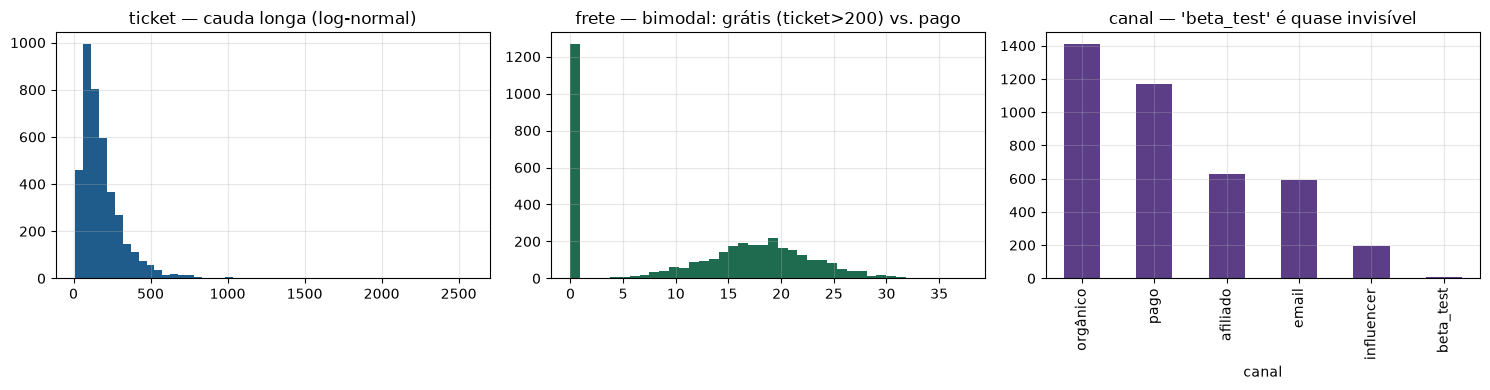

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(pedidos_limpo["ticket"], bins=50, color=AZUL)
axes[0].set_title("ticket — cauda longa (log-normal)")
axes[1].hist(pedidos_limpo["frete"].dropna(), bins=40, color=VERDE)
axes[1].set_title("frete — bimodal: grátis (ticket>200) vs. pago")
pedidos_limpo["canal"].value_counts().plot(kind="bar", ax=axes[2], color=ROXO)
axes[2].set_title("canal — 'beta_test' é quase invisível")
plt.tight_layout(); plt.show()

## Etapa 3 — Categorias raras: um aviso antecipado

`beta_test` tem 6 casos em ~4000 — qualquer split de treino/teste tem risco
real de deixar essa categoria de fora de um dos lados, e um one-hot nela cria
uma coluna quase sempre zero.

In [8]:
freq_canal = pedidos_limpo["canal"].value_counts(normalize=True)
print(freq_canal.round(4))
print(f"\ncategorias com menos de 1% dos dados: "
      f"{list(freq_canal[freq_canal < 0.01].index)}")
print("-> candidatas a agrupar em 'outros' antes do encoding (módulo 4).")

canal
orgânico      0.3525
pago          0.2925
afiliado      0.1565
email         0.1485
influencer    0.0485
beta_test     0.0015
Name: proportion, dtype: float64

categorias com menos de 1% dos dados: ['beta_test']
-> candidatas a agrupar em 'outros' antes do encoding (módulo 4).


## Etapa 4 — Hipóteses e checagem de vazamento

Suponha o objetivo: prever `confirmado` a partir das outras colunas. Vamos
checar quais features "previsíveis demais" merecem suspeita.

In [9]:
from sklearn.feature_selection import mutual_info_classif

candidatas = pedidos_limpo[["ticket", "frete", "idade_conta_dias"]].fillna(0)
alvo = pedidos_limpo["confirmado"]

mi = mutual_info_classif(candidatas, alvo, random_state=0)
for col, valor in zip(candidatas.columns, mi):
    print(f"{col:<20s} informação mútua com 'confirmado' = {valor:.4f}")

print(f"\nAGORA incluindo 'dias_ate_confirmacao' (preenchendo nulo com um valor "
      f"grande, como se fosse feature):")
candidatas_com_vazamento = candidatas.copy()
candidatas_com_vazamento["dias_ate_confirmacao"] = (
    pedidos_limpo["dias_ate_confirmacao"].fillna(999))
mi2 = mutual_info_classif(candidatas_com_vazamento, alvo, random_state=0)
for col, valor in zip(candidatas_com_vazamento.columns, mi2):
    marca = "  <-- MUITO alto, suspeito" if valor > 0.3 else ""
    print(f"{col:<20s} informação mútua = {valor:.4f}{marca}")

ticket               informação mútua com 'confirmado' = 0.0000
frete                informação mútua com 'confirmado' = 0.0037
idade_conta_dias     informação mútua com 'confirmado' = 0.0000

AGORA incluindo 'dias_ate_confirmacao' (preenchendo nulo com um valor grande, como se fosse feature):
ticket               informação mútua = 0.0000
frete                informação mútua = 0.0020
idade_conta_dias     informação mútua = 0.0000
dias_ate_confirmacao informação mútua = 0.5522  <-- MUITO alto, suspeito


**O vazamento fica óbvio na informação mútua.** `dias_ate_confirmacao` é
preenchido (por construção) só quando `confirmado==1` — usá-la como feature é
literalmente usar o resultado para prever o resultado. Isso é fácil de ver
neste exemplo didático; em dados reais, o padrão a procurar é: **"essa
coluna só existe/é preenchida depois do evento que quero prever?"**

## O que levar deste notebook

- A ordem do protocolo importa: forma → perfil univariado → relações →
  hipóteses. Pular para "relações" sem checar dtypes e nulos gera conclusões
  erradas.
- Nulo **estrutural** (não pode existir, por definição) e nulo **aleatório**
  (poderia existir, mas faltou) exigem tratamentos completamente diferentes —
  distingui-los é o primeiro passo do módulo 2.
- Cardinalidade e categorias raras detectadas agora evitam surpresas no
  encoding (módulo 4).
- Informação mútua anormalmente alta com o alvo é o sinal de alerta mais
  confiável de vazamento de dados.

→ Próximo: **Relações e correlação**, o vocabulário completo de medidas de
associação.